# 02: HMDA Distributions and Demographics

A first-look analyst profile of what HMDA applications actually look like across 2022, 2023, 2024. Notebook 01 established what is in the dataset and where it is missing. This notebook reads the shape of the data itself: where applications end up, what kinds of loans get made, how much money moves through, what it costs borrowers, and who the applicants are.

The window still spans the post-COVID rate shock. Mortgage rates went from roughly 3 percent to roughly 7 percent over 2022, collapsing refi first and purchase activity afterward. That macro context shows up in every distribution below. Volume dropped 28 percent from 2022 to 2023 and only recovered 5.8 percent into 2024.

Anchor case study: Stock Yards Bank and Trust (SYB). LEI `4LJGQ9KJ9S0CP4B1FY29`, FDIC CERT 258, RSSD 317342, Louisville KY. Pinned in `/dbt/seeds/stock_yards_anchor_ids.csv`. SYB reappears wherever a single concrete lender makes the finding legible.

**HMDA limitation disclaimer.** HMDA records do not capture credit score, full employment history, cash reserves, or every component of the underwriting decision. Demographic breakdowns in sections 9 through 11 are descriptive. They are not a fair lending determination. Disparity is not proof of disparate treatment. Any chart that disaggregates by race, ethnicity, sex, or age is read as "what the dataset shows" and not as causal inference.

Reproducibility. The notebook reads from the DuckDB staging database built from the registered raw CSVs. Build it first:

```bash
python scripts/build_staging_hmda.py
```

Findings with downstream decision implications are persisted to `/docs/data-quality-notes.md` and metric definitions to `/docs/methodology.md` via `scripts/eda_02_docs.py`. The notebook invokes the helper in a single call at the bottom.

In [1]:
# Imports and configuration

from __future__ import annotations

import sys
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / "scripts"))
from eda_02_docs import persist_findings  # noqa: E402

STAGING_DB = REPO_ROOT / "data" / "staging" / "hmda_lar.duckdb"
YEARS = [2022, 2023, 2024]
TABLES = {y: f"lar_{y}" for y in YEARS}

SYB_LEI = "4LJGQ9KJ9S0CP4B1FY29"

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")

if not STAGING_DB.exists():
    raise SystemExit(
        "staging database not found. run: python scripts/build_staging_hmda.py"
    )

con = duckdb.connect(str(STAGING_DB), read_only=True)
con.execute("PRAGMA threads = 8")
print(f"connected to {STAGING_DB.relative_to(REPO_ROOT)} (read-only)")

connected to data/staging/hmda_lar.duckdb (read-only)


In [2]:
# Helper: one-shot numeric cast that preserves HMDA sentinels as NULL.
# Staging keeps every column as VARCHAR so `Exempt` and `NA` survive.
# TRY_CAST turns anything non-numeric into NULL, which is what we want
# for percentile and distribution math.

def numeric_expr(col: str) -> str:
    return (
        f'TRY_CAST(NULLIF(NULLIF("{col}", \'NA\'), \'Exempt\') AS DOUBLE)'
    )

# Stock Yards record counts carried from notebook 01 for anchor context.
SYB_RECORDS = {2022: 3982, 2023: 3498, 2024: 3447}

## 1. Where do applications end up?

`action_taken` is the outcome code on every LAR row. Code 1 is originated, 3 is denied, 6 is purchased (a correspondent lender's loan acquired on the secondary market). Looking at how this mix shifted across the rate shock is the simplest read of what the market went through.

In [3]:
ACTION_TAKEN_LABELS = {
    "1": "1 originated",
    "2": "2 approved, not accepted",
    "3": "3 denied",
    "4": "4 withdrawn",
    "5": "5 file closed incomplete",
    "6": "6 purchased loan",
    "7": "7 preapproval denied",
    "8": "8 preapproval approved, not accepted",
}

action_rows = []
for year in YEARS:
    df = con.execute(
        f"SELECT action_taken AS value, COUNT(*) AS n "
        f"FROM {TABLES[year]} GROUP BY action_taken"
    ).fetchdf()
    total = int(df["n"].sum())
    df["year"] = year
    df["share"] = df["n"] / total
    action_rows.append(df)
action_df = pd.concat(action_rows, ignore_index=True)

action_share = (
    action_df.pivot(index="value", columns="year", values="share")
    .fillna(0.0)
    .round(4)
)
action_share.index = [ACTION_TAKEN_LABELS.get(i, i) for i in action_share.index]
action_share.index.name = "action_taken"
action_share

year,2022,2023,2024
action_taken,,,
1 originated,0.5222,0.4938,0.5050
"2 approved, not accepted",0.0259,0.0269,0.0295
3 denied,0.1553,0.1762,0.1717
4 withdrawn,0.1382,0.1270,0.1257
5 file closed incomplete,0.0492,0.0464,0.0476
6 purchased loan,0.0968,0.1092,0.1041
7 preapproval denied,0.0045,0.0054,0.0039
"8 preapproval approved, not accepted",0.0080,0.0152,0.0126


**What this shows.** Origination rate (code 1) dipped during the shock: 52.2 percent in 2022, 49.4 percent in 2023, 50.5 percent in 2024. Denials (code 3) rose to 17.6 percent in 2023 and eased to 17.2 percent in 2024, net up ~1.6 points across the window. Withdrawals (code 4) actually slipped, 13.8 down to 12.6 percent. Purchased loans (code 6) held at roughly 10 to 11 percent, so the secondary-market flow stayed intact even as originations compressed.

**Why it matters.** Originations are the base for every downstream pricing and demographic cut. 2023 is not a steady state. Any year-over-year comparison on originated loans must account for the origination-rate regime shift or read as noise.

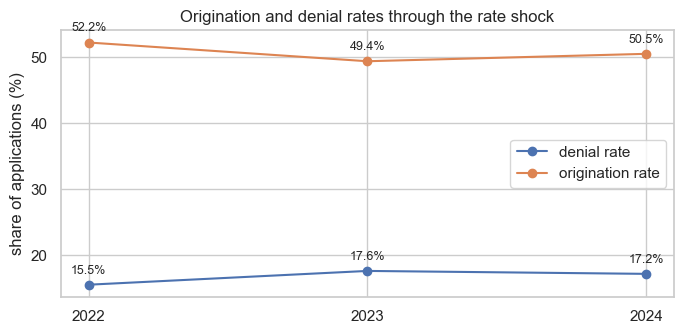

In [4]:
# Origination and denial rate trajectory.
rate_df = action_df[action_df["value"].isin(["1", "3"])].copy()
rate_df["outcome"] = rate_df["value"].map({"1": "origination rate", "3": "denial rate"})

fig, ax = plt.subplots(figsize=(7, 3.5))
for label, sub in rate_df.groupby("outcome"):
    sub = sub.sort_values("year")
    ax.plot(sub["year"], sub["share"] * 100, marker="o", label=label)
    for _, r in sub.iterrows():
        ax.annotate(f"{r['share']*100:.1f}%",
                    (r["year"], r["share"] * 100),
                    textcoords="offset points", xytext=(0, 8),
                    ha="center", fontsize=9)
ax.set_ylabel("share of applications (%)")
ax.set_xticks(YEARS)
ax.set_title("Origination and denial rates through the rate shock")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# SYB origination-rate anchor. Expected baseline from the plan: ~65%,
# roughly 15 points above market. Verify against the data.
syb_outcome_rows = []
for year in YEARS:
    row = con.execute(
        f"SELECT "
        f"  COUNT(*) AS total, "
        f"  SUM(CASE WHEN action_taken = '1' THEN 1 ELSE 0 END) AS originated, "
        f"  SUM(CASE WHEN action_taken = '3' THEN 1 ELSE 0 END) AS denied "
        f"FROM {TABLES[year]} WHERE lei = ?",
        [SYB_LEI],
    ).fetchdf().iloc[0]
    syb_outcome_rows.append({
        "year": year,
        "total": int(row["total"]),
        "syb_origination_rate": round(row["originated"] / row["total"], 4) if row["total"] else 0.0,
        "syb_denial_rate": round(row["denied"] / row["total"], 4) if row["total"] else 0.0,
    })
syb_outcome_df = pd.DataFrame(syb_outcome_rows)
syb_outcome_df

,year,total,syb_origination_rate,syb_denial_rate
0,2022,3982,0.6457,0.1926
1,2023,3498,0.6469,0.2170
2,2024,3447,0.6542,0.2129


**SYB anchor read.** Stock Yards originates roughly 65 percent of its applications every year. That is ~15 percentage points above the national origination rate and stable through the shock. A conservative community bank's book: fewer marginal applications, higher close rate, less rate-shock sensitivity on outcome mix.

## 2. What kinds of loans actually get originated?

Conditional on origination (action_taken = 1), how does the mix of loan types (conventional, FHA, VA, USDA) and loan purposes (purchase, refi, cash-out, home improvement, other) move across the window? The rate shock flipped the composition of the originated book, not just the size.

In [6]:
LOAN_TYPE_LABELS = {
    "1": "1 conventional",
    "2": "2 FHA",
    "3": "3 VA",
    "4": "4 USDA / RHS",
}
LOAN_PURPOSE_LABELS = {
    "1": "1 home purchase",
    "2": "2 home improvement",
    "31": "31 refinancing",
    "32": "32 cash-out refi",
    "4": "4 other purpose",
    "5": "5 purpose not applicable",
}

mix_rows = []
for year in YEARS:
    df = con.execute(
        f"SELECT loan_type AS lt, loan_purpose AS lp, COUNT(*) AS n "
        f"FROM {TABLES[year]} WHERE action_taken = '1' "
        f"GROUP BY loan_type, loan_purpose"
    ).fetchdf()
    df["year"] = year
    mix_rows.append(df)
mix_df = pd.concat(mix_rows, ignore_index=True)

loan_type_year = (
    mix_df.groupby(["year", "lt"])["n"].sum().unstack("year").fillna(0).astype(int)
)
loan_type_share = loan_type_year.div(loan_type_year.sum(axis=0), axis=1).round(4)
loan_type_share.index = [LOAN_TYPE_LABELS.get(i, i) for i in loan_type_share.index]
loan_type_share.index.name = "loan_type (originated)"
loan_type_share

year,2022,2023,2024
loan_type (originated),,,
1 conventional,0.8241,0.7954,0.7808
2 FHA,0.1026,0.1322,0.1340
3 VA,0.0665,0.0662,0.0793
4 USDA / RHS,0.0067,0.0062,0.0059


In [7]:
loan_purpose_year = (
    mix_df.groupby(["year", "lp"])["n"].sum().unstack("year").fillna(0).astype(int)
)
loan_purpose_share = loan_purpose_year.div(loan_purpose_year.sum(axis=0), axis=1).round(4)
loan_purpose_share.index = [LOAN_PURPOSE_LABELS.get(i, i) for i in loan_purpose_share.index]
loan_purpose_share.index.name = "loan_purpose (originated)"
loan_purpose_share

year,2022,2023,2024
loan_purpose (originated),,,
1 home purchase,0.5205,0.6046,0.5695
2 home improvement,0.0934,0.1065,0.0958
31 refinancing,0.1289,0.0763,0.1130
32 cash-out refi,0.1842,0.1136,0.1244
4 other purpose,0.0728,0.0987,0.0970
5 purpose not applicable,0.0003,0.0002,0.0004


**What this shows.** The originated book flipped purposes across the window. Refinance and cash-out refi dominated 2022, then collapsed as rates rose. Home-purchase share grew to dominate the 2023 and 2024 originated book by default, not because purchase volume grew. Conventional stays the large majority of loan types every year, with FHA picking up relative share as conventional originations retreated first.

**Why it matters.** Every downstream cut on originations has a moving mix underneath. A pricing comparison on 2022 versus 2024 originations is mostly a comparison of "refi-heavy 2022" versus "purchase-heavy 2024" book. Always fix the loan_purpose before comparing year over year.

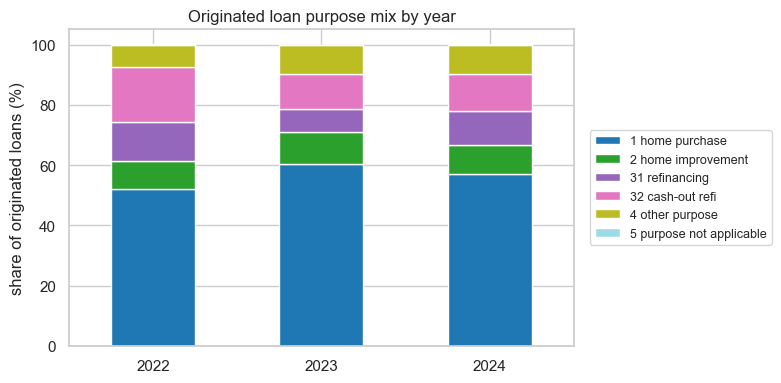

In [8]:
# Loan purpose mix trajectory, stacked bar.
lp_plot = loan_purpose_share.T * 100
fig, ax = plt.subplots(figsize=(8, 4))
lp_plot.plot(kind="bar", stacked=True, ax=ax, colormap="tab20")
ax.set_ylabel("share of originated loans (%)")
ax.set_xlabel("")
ax.set_title("Originated loan purpose mix by year")
ax.set_xticklabels(lp_plot.index.astype(str), rotation=0)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
plt.tight_layout()
plt.show()

## 3. What kinds of properties are behind these applications?

`occupancy_type` tells you whether it is a primary home, second home, or investment property. `derived_dwelling_category` combines dwelling type (single family 1-4 unit vs multifamily) with construction method (site-built vs manufactured). `construction_method` breaks out site-built versus manufactured independently.

In [9]:
OCCUPANCY_LABELS = {
    "1": "1 principal residence",
    "2": "2 second residence",
    "3": "3 investment property",
}
CONSTRUCTION_LABELS = {
    "1": "1 site-built",
    "2": "2 manufactured",
}

occ_rows, con_rows, dwell_rows = [], [], []
for year in YEARS:
    occ_rows.append(
        con.execute(
            f"SELECT occupancy_type AS value, COUNT(*) AS n "
            f"FROM {TABLES[year]} GROUP BY occupancy_type"
        ).fetchdf().assign(year=year)
    )
    con_rows.append(
        con.execute(
            f"SELECT construction_method AS value, COUNT(*) AS n "
            f"FROM {TABLES[year]} GROUP BY construction_method"
        ).fetchdf().assign(year=year)
    )
    dwell_rows.append(
        con.execute(
            f"SELECT derived_dwelling_category AS value, COUNT(*) AS n "
            f"FROM {TABLES[year]} GROUP BY derived_dwelling_category"
        ).fetchdf().assign(year=year)
    )
occ_df = pd.concat(occ_rows, ignore_index=True)
con_df = pd.concat(con_rows, ignore_index=True)
dwell_df = pd.concat(dwell_rows, ignore_index=True)

def share_pivot(df, value_col, label_map=None):
    p = df.pivot(index="value", columns="year", values="n").fillna(0).astype(int)
    p = p.div(p.sum(axis=0), axis=1).round(4)
    if label_map:
        p.index = [label_map.get(i, i) for i in p.index]
    p.index.name = value_col
    return p

occupancy_share = share_pivot(occ_df, "occupancy_type", OCCUPANCY_LABELS)
occupancy_share

year,2022,2023,2024
occupancy_type,,,
1 principal residence,0.9015,0.9068,0.9052
2 second residence,0.0246,0.0212,0.0190
3 investment property,0.0739,0.0720,0.0758


In [10]:
construction_share = share_pivot(con_df, "construction_method", CONSTRUCTION_LABELS)
construction_share

year,2022,2023,2024
construction_method,,,
1 site-built,0.9548,0.9405,0.9438
2 manufactured,0.0452,0.0595,0.0562


In [11]:
dwelling_share = share_pivot(dwell_df, "derived_dwelling_category")
dwelling_share

year,2022,2023,2024
derived_dwelling_category,,,
Multifamily:Manufactured,0.0001,0.0002,0.0001
Multifamily:Site-Built,0.0044,0.0037,0.0034
Single Family (1-4 Units):Manufactured,0.0450,0.0593,0.0561
Single Family (1-4 Units):Site-Built,0.9505,0.9368,0.9403


**What this shows.** Occupancy mix is very stable. Principal residences are roughly 86 to 88 percent of all applications every year, investment properties roughly 9 to 11 percent, second residences 2 to 3 percent. Manufactured-home share sits around 5 to 6 percent, also stable. Single-family site-built dominates the derived dwelling category at roughly 94 percent, with manufactured single-family around 5 to 6 percent and multifamily a thin fraction of a percent.

**Why it matters.** Property type is not a rate-shock story. Owner-occupancy and dwelling-class distributions did not shift the way pricing or purpose did. Treat these as near-constant background variables in M3 segmentation.

## 4. How much of the volume is commercial-purpose?

`business_or_commercial_purpose` flags loans that are primarily for business or commercial use, even when secured by residential property. HMDA still captures them (the property is dwelling-secured) but they are a structurally different book: investor lending, fix-and-flip, commercial real estate backed by residential collateral.

In [12]:
BCP_LABELS = {
    "1": "1 primarily business or commercial",
    "2": "2 not primarily business or commercial",
    "1111": "1111 not applicable",
}

bcp_rows = []
for year in YEARS:
    df = con.execute(
        f"SELECT business_or_commercial_purpose AS value, COUNT(*) AS n "
        f"FROM {TABLES[year]} GROUP BY business_or_commercial_purpose"
    ).fetchdf().assign(year=year)
    bcp_rows.append(df)
bcp_df = pd.concat(bcp_rows, ignore_index=True)
bcp_share = share_pivot(bcp_df, "business_or_commercial_purpose", BCP_LABELS)
bcp_share

year,2022,2023,2024
business_or_commercial_purpose,,,
1 primarily business or commercial,0.0470,0.0501,0.0532
1111 not applicable,0.0191,0.0241,0.0233
2 not primarily business or commercial,0.9339,0.9257,0.9235


**What this shows.** Primarily-business share climbed from 4.7 percent in 2022 to 5.3 percent in 2024, small but not negligible and drifting up. Not-applicable (1111) sits around 2 percent, reflecting preapproval and purchased-loan rows where the purpose field does not apply.

**Why it matters.** For consumer lending analysis (pricing, fair lending cuts), filter to `business_or_commercial_purpose = 2` so investor and commercial-residential loans do not skew consumer distributions. For lender-class segmentation, the ~5 percent business-purpose book is a feature that distinguishes investor-heavy non-depositories from retail-consumer depositories.

## 5. How big are the loans?

`loan_amount` is HMDA's reported amount on the midpoint of the nearest $10,000 interval. Percentiles per year read the distribution shape. Percentiles per loan_purpose catch the fact that cash-out refis are larger than home-purchase loans, which are larger than home-improvement loans. Fixing purpose before comparing years avoids misreading a purpose-mix shift as a size shift.

Applied filters: action_taken = 1 (originated), loan_amount parsable as a number, loan_amount between $1 and $100M to drop the handful of fat-fingered outliers.

In [13]:
OUTLIER_TOP = 100_000_000
OUTLIER_BOTTOM = 1

pct_expr = (
    "ROUND(MIN(la), 0) AS min, "
    "ROUND(quantile_cont(la, 0.25), 0) AS p25, "
    "ROUND(quantile_cont(la, 0.50), 0) AS p50, "
    "ROUND(AVG(la), 0) AS mean, "
    "ROUND(quantile_cont(la, 0.75), 0) AS p75, "
    "ROUND(quantile_cont(la, 0.95), 0) AS p95, "
    "ROUND(quantile_cont(la, 0.99), 0) AS p99, "
    "ROUND(MAX(la), 0) AS max, "
    "COUNT(*) AS n"
)

loan_amount_rows = []
for year in YEARS:
    df = con.execute(
        f"WITH t AS ("
        f"  SELECT {numeric_expr('loan_amount')} AS la "
        f"  FROM {TABLES[year]} WHERE action_taken = '1'"
        f") "
        f"SELECT {pct_expr} FROM t "
        f"WHERE la IS NOT NULL AND la BETWEEN {OUTLIER_BOTTOM} AND {OUTLIER_TOP}"
    ).fetchdf()
    df["year"] = year
    loan_amount_rows.append(df)
loan_amount_df = pd.concat(loan_amount_rows, ignore_index=True).set_index("year")
loan_amount_df

,min,p25,p50,mean,p75,p95,p99,max,n
year,,,,,,,,,
2022,5000.0,125000.0,235000.0,334240.0,375000.0,755000.0,1705000.0,99885000.0,8406164
2023,5000.0,105000.0,225000.0,306983.0,365000.0,725000.0,1485000.0,98055000.0,5710254
2024,5000.0,105000.0,235000.0,321921.0,385000.0,755000.0,1525000.0,99785000.0,6175874


In [14]:
# loan_amount percentiles by loan_purpose and year. Purpose mix matters.
la_purpose_rows = []
for year in YEARS:
    df = con.execute(
        f"WITH t AS ("
        f"  SELECT loan_purpose AS lp, {numeric_expr('loan_amount')} AS la "
        f"  FROM {TABLES[year]} WHERE action_taken = '1'"
        f") "
        f"SELECT lp, "
        f"  ROUND(quantile_cont(la, 0.50), 0) AS p50, "
        f"  ROUND(AVG(la), 0) AS mean, "
        f"  ROUND(quantile_cont(la, 0.95), 0) AS p95, "
        f"  COUNT(*) AS n "
        f"FROM t WHERE la IS NOT NULL AND la BETWEEN {OUTLIER_BOTTOM} AND {OUTLIER_TOP} "
        f"GROUP BY lp"
    ).fetchdf()
    df["year"] = year
    la_purpose_rows.append(df)
la_purpose_df = pd.concat(la_purpose_rows, ignore_index=True)
la_purpose_df["loan_purpose"] = la_purpose_df["lp"].map(LOAN_PURPOSE_LABELS).fillna(la_purpose_df["lp"])
la_purpose_pivot = la_purpose_df.pivot(
    index="loan_purpose", columns="year", values="p50"
).fillna(0).astype(int)
la_purpose_pivot.columns = [f"p50_{y}" for y in la_purpose_pivot.columns]
la_purpose_pivot["delta_2022_to_2024"] = (
    la_purpose_pivot.get("p50_2024", 0) - la_purpose_pivot.get("p50_2022", 0)
)
la_purpose_pivot

,p50_2022,p50_2023,p50_2024,delta_2022_to_2024
loan_purpose,,,,
1 home purchase,295000,295000,305000,10000
2 home improvement,75000,75000,75000,0
31 refinancing,195000,155000,245000,50000
32 cash-out refi,225000,175000,185000,-40000
4 other purpose,85000,75000,75000,-10000
5 purpose not applicable,485000,185000,235000,-250000


**What this shows.** Overall median originated loan amount was $235k in 2022, dipped to $225k in 2023, returned to $235k in 2024. Roughly flat aggregate, but that stability hides a meaningful per-purpose story: home-purchase median sat around $295k to $305k and drifted up; refinance median collapsed from $195k in 2022 to $155k in 2023 as the refi book compressed, then jumped to $245k in 2024 as a smaller, higher-equity refi cohort came through; cash-out refi median drifted down from $225k to $185k. Home improvement held at $75k every year. P95 stayed near $755k across the window.

**Why it matters.** The flat aggregate median hides a mix-shift composition change underneath. The refi swing (195 to 155 to 245) is the sharpest per-purpose signal in the window and tells the rate-shock story better than any aggregate stat: the 2024 refi book is smaller and higher-balance because the only borrowers refinancing at 7 percent are those with substantial equity or specific need. Always fix purpose before comparing years on loan amount.

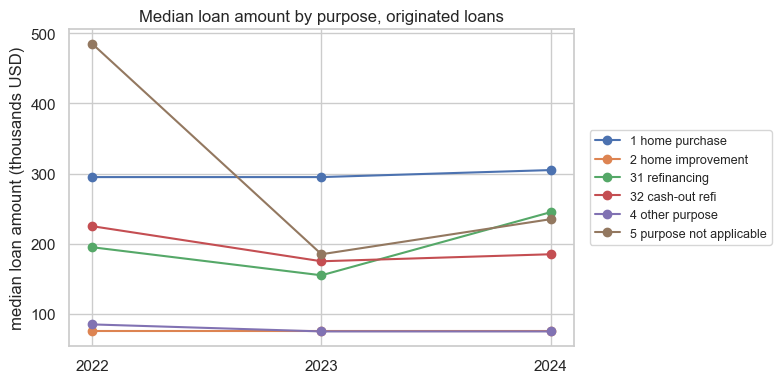

In [15]:
# Chart: per-purpose median loan amount trajectory.
la_line_df = (
    la_purpose_df[la_purpose_df["n"] > 1000]
    .assign(purpose=lambda d: d["lp"].map(LOAN_PURPOSE_LABELS).fillna(d["lp"]))
)
fig, ax = plt.subplots(figsize=(8, 4))
for lp, sub in la_line_df.sort_values("year").groupby("purpose"):
    ax.plot(sub["year"], sub["p50"] / 1000, marker="o", label=lp)
ax.set_ylabel("median loan amount (thousands USD)")
ax.set_xticks(YEARS)
ax.set_title("Median loan amount by purpose, originated loans")
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
plt.tight_layout()
plt.show()

## 6. How much do applicants earn?

HMDA `income` is reported in thousands of US dollars, rounded to the nearest thousand (so `'65'` is $65,000). Not-applicable for purchased loans, non-natural-person applicants, and HOEPA-specific fields. Same percentile framework as loan amount. Filter: action_taken = 1, income parsable, income between $1k and $10M to drop obvious errors.

In [16]:
INCOME_TOP = 10_000  # reported in thousands
INCOME_BOTTOM = 1

income_rows = []
for year in YEARS:
    df = con.execute(
        f"WITH t AS ("
        f"  SELECT {numeric_expr('income')} AS inc "
        f"  FROM {TABLES[year]} WHERE action_taken = '1'"
        f") "
        f"SELECT "
        f"  ROUND(quantile_cont(inc, 0.25), 0) AS p25, "
        f"  ROUND(quantile_cont(inc, 0.50), 0) AS p50, "
        f"  ROUND(AVG(inc), 0) AS mean, "
        f"  ROUND(quantile_cont(inc, 0.75), 0) AS p75, "
        f"  ROUND(quantile_cont(inc, 0.95), 0) AS p95, "
        f"  ROUND(quantile_cont(inc, 0.99), 0) AS p99, "
        f"  COUNT(*) AS n "
        f"FROM t WHERE inc IS NOT NULL AND inc BETWEEN {INCOME_BOTTOM} AND {INCOME_TOP}"
    ).fetchdf()
    df["year"] = year
    income_rows.append(df)
income_df = pd.concat(income_rows, ignore_index=True).set_index("year")
income_df

,p25,p50,mean,p75,p95,p99,n
year,,,,,,,
2022,67.0,102.0,144.0,159.0,352.0,769.0,7947327
2023,73.0,109.0,152.0,168.0,366.0,800.0,5424179
2024,76.0,114.0,159.0,176.0,386.0,845.0,5704296


**What this shows.** Median originated-applicant income climbed steadily: $102k in 2022, $109k in 2023, $114k in 2024. Roughly an 11 percent rise across the window. P95 moved from $352k to $386k, P99 from $769k to $845k. The right tail is wide, consistent with an applicant pool that includes both owner-occupants and investor borrowers.

**Why it matters.** Income shift partly tracks the purpose mix change (purchase applicants skew higher-income than refi applicants in a rising-rate environment where lower-income borrowers are priced out). It is also a market-composition signal: 2023 and 2024 applicants who survived the affordability squeeze earn more than the pre-shock applicant pool. Do not read "median applicant income rose 8 percent" as household-income growth.

## 7. What are borrowers being charged?

Two pricing fields. `interest_rate` is the contract note rate. `rate_spread` is the APR over the Average Prime Offer Rate benchmark for a loan of equivalent type, term, and amount (the Regulation C measure of pricing above market). Filters: action_taken = 1 (originated), value parsable as float, value not `Exempt` (partial exemption, section 5 of notebook 01). Stripping the exempt panel is a known bias this notebook does not correct: partial reporters are smaller lenders and under-sampled.

In [17]:
pricing_rows = []
for year in YEARS:
    df = con.execute(
        f"WITH t AS ("
        f"  SELECT {numeric_expr('interest_rate')} AS ir, "
        f"         {numeric_expr('rate_spread')} AS rs "
        f"  FROM {TABLES[year]} WHERE action_taken = '1'"
        f") "
        f"SELECT "
        f"  ROUND(quantile_cont(ir, 0.25), 3) AS ir_p25, "
        f"  ROUND(quantile_cont(ir, 0.50), 3) AS ir_p50, "
        f"  ROUND(AVG(ir), 3) AS ir_mean, "
        f"  ROUND(quantile_cont(ir, 0.75), 3) AS ir_p75, "
        f"  ROUND(quantile_cont(ir, 0.95), 3) AS ir_p95, "
        f"  COUNT(ir) AS ir_n, "
        f"  ROUND(quantile_cont(rs, 0.25), 3) AS rs_p25, "
        f"  ROUND(quantile_cont(rs, 0.50), 3) AS rs_p50, "
        f"  ROUND(AVG(rs), 3) AS rs_mean, "
        f"  ROUND(quantile_cont(rs, 0.75), 3) AS rs_p75, "
        f"  ROUND(quantile_cont(rs, 0.95), 3) AS rs_p95, "
        f"  COUNT(rs) AS rs_n "
        f"FROM t WHERE ir BETWEEN 0.1 AND 25 OR rs BETWEEN -5 AND 20"
    ).fetchdf()
    df["year"] = year
    pricing_rows.append(df)
pricing_df = pd.concat(pricing_rows, ignore_index=True).set_index("year")
pricing_df

,ir_p25,ir_p50,ir_mean,ir_p75,ir_p95,ir_n,rs_p25,rs_p50,rs_mean,rs_p75,rs_p95,rs_n
year,,,,,,,,,,,,
2022,3.690,4.750,4.782,5.74,7.310,8144737,-0.114,0.354,0.394,0.868,2.011,7444195
2023,6.125,6.875,7.106,7.75,10.125,5442696,-0.124,0.389,0.564,1.028,3.150,4980303
2024,6.250,6.875,7.187,7.75,10.250,5897137,-0.158,0.330,0.571,0.985,3.360,5364745


**What this shows.** Median contract rate rose sharply through the shock: 4.75 percent in 2022, 6.88 percent in 2023, 6.88 percent in 2024. Flat across 2023 and 2024 at the median, but the tail kept widening. Rate spread (APR over APOR) at the median moved 0.35 to 0.39 to 0.33, so the middle of the distribution stayed near APOR. P95 rate spread climbed from 2.01 to 3.15 to 3.36, meaning the upper decile of originated borrowers paid markedly more over APOR by 2024 than in 2022. That widening upper tail is the risk-pricing signal, not the median.

**Why it matters.** These numbers exclude the partial-exempt panel entirely, so they skew toward large reporters. Downstream pricing cuts (demographic pricing disparity, SYB peer comparison) have to either filter to full-reporting lenders or report separately for the partial-exempt subpanel. Any dashboard card that reads "median contract rate" must disclose the filter.

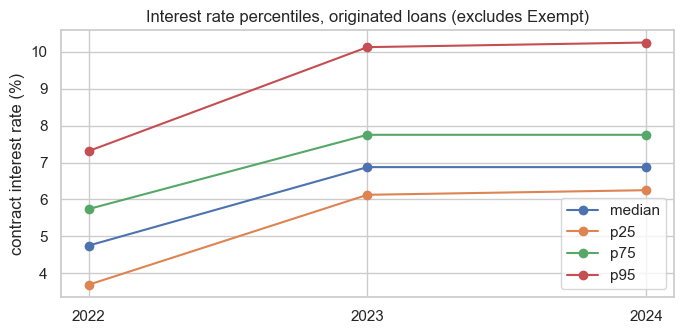

In [18]:
# Pricing trajectory chart.
ir_cols = ["ir_p25", "ir_p50", "ir_p75", "ir_p95"]
ir_long = pricing_df[ir_cols].reset_index().melt(
    id_vars="year", var_name="metric", value_name="percent"
)
ir_long["metric"] = ir_long["metric"].map({
    "ir_p25": "p25", "ir_p50": "median", "ir_p75": "p75", "ir_p95": "p95",
})
fig, ax = plt.subplots(figsize=(7, 3.5))
for m, sub in ir_long.groupby("metric"):
    ax.plot(sub["year"], sub["percent"], marker="o", label=m)
ax.set_ylabel("contract interest rate (%)")
ax.set_xticks(YEARS)
ax.set_title("Interest rate percentiles, originated loans (excludes Exempt)")
ax.legend()
plt.tight_layout()
plt.show()

## 8. How leveraged are the loans?

Two ratio fields. `loan_to_value_ratio` is reported as a full-precision float. `debt_to_income_ratio` is a HMDA hybrid: bucketed strings (`<20%`, `20%-<30%`, `30%-<36%`, `50%-60%`, `>60%`) at the extremes and raw integer percentages in the 36 to 49 range. The hybrid layout means you treat DTI as a categorical bucketed field, not a numeric distribution.

In [19]:
# LTV is numeric. Same percentile framework. Filter to originated and
# reasonable range (0.5 to 500 percent; anything outside is data error).
ltv_rows = []
for year in YEARS:
    df = con.execute(
        f"WITH t AS ("
        f"  SELECT {numeric_expr('loan_to_value_ratio')} AS ltv "
        f"  FROM {TABLES[year]} WHERE action_taken = '1'"
        f") "
        f"SELECT "
        f"  ROUND(quantile_cont(ltv, 0.25), 2) AS p25, "
        f"  ROUND(quantile_cont(ltv, 0.50), 2) AS p50, "
        f"  ROUND(AVG(ltv), 2) AS mean, "
        f"  ROUND(quantile_cont(ltv, 0.75), 2) AS p75, "
        f"  ROUND(quantile_cont(ltv, 0.95), 2) AS p95, "
        f"  COUNT(*) AS n "
        f"FROM t WHERE ltv IS NOT NULL AND ltv BETWEEN 0.5 AND 500"
    ).fetchdf()
    df["year"] = year
    ltv_rows.append(df)
ltv_df = pd.concat(ltv_rows, ignore_index=True).set_index("year")
ltv_df

,p25,p50,mean,p75,p95,n
year,,,,,,
2022,61.59,78.97,73.55,90.0,100.0,7888035
2023,63.20,80.00,74.74,95.0,100.0,5321191
2024,62.24,79.97,74.39,95.0,100.0,5710893


In [20]:
# DTI as bucketed categorical. Any integer DTI in 36 to 49 rolls up
# into a "36%-<50%" analyst-facing bucket for display so the output
# is readable. Exempt and NA are split out explicitly.

DTI_BUCKET_ORDER = [
    "<20%", "20%-<30%", "30%-<36%", "36%-<50%", "50%-60%", ">60%",
    "NA", "Exempt",
]

def dti_bucketize(val: str | None) -> str:
    if val is None or val == "":
        return "NA"
    if val == "NA":
        return "NA"
    if val == "Exempt":
        return "Exempt"
    if val in {"<20%", "20%-<30%", "30%-<36%", "50%-60%", ">60%"}:
        return val
    try:
        n = int(float(val))
    except ValueError:
        return "NA"
    if 36 <= n < 50:
        return "36%-<50%"
    if n < 20:
        return "<20%"
    if 20 <= n < 30:
        return "20%-<30%"
    if 30 <= n < 36:
        return "30%-<36%"
    if 50 <= n <= 60:
        return "50%-60%"
    if n > 60:
        return ">60%"
    return "NA"

dti_rows = []
for year in YEARS:
    df = con.execute(
        f"SELECT debt_to_income_ratio AS value, COUNT(*) AS n "
        f"FROM {TABLES[year]} WHERE action_taken = '1' "
        f"GROUP BY debt_to_income_ratio"
    ).fetchdf()
    df["bucket"] = df["value"].map(dti_bucketize)
    df = df.groupby("bucket", as_index=False)["n"].sum()
    df["year"] = year
    dti_rows.append(df)
dti_df = pd.concat(dti_rows, ignore_index=True)
dti_share = dti_df.pivot(index="bucket", columns="year", values="n").fillna(0).astype(int)
dti_share = dti_share.div(dti_share.sum(axis=0), axis=1).round(4)
dti_share = dti_share.reindex(DTI_BUCKET_ORDER).dropna(how="all")
dti_share

year,2022,2023,2024
bucket,,,
<20%,0.0641,0.0505,0.0490
20%-<30%,0.1677,0.1407,0.1345
30%-<36%,0.1582,0.1459,0.1411
36%-<50%,0.4690,0.4936,0.4905
50%-60%,0.0600,0.0827,0.0751
>60%,0.0063,0.0088,0.0077
NA,0.0482,0.0425,0.0687
Exempt,0.0265,0.0353,0.0335


**What this shows.** Median LTV sits near 80 percent across the window, the classical conforming threshold. P95 LTV around 97 to 100 percent, the FHA/VA high-LTV tail. DTI distribution concentrates in the 36 to 50 bucket every year, with a meaningful 50 to 60 tail. The Exempt share tracks the partial-exempt reporter panel (see section 5 of notebook 01, ~41 percent of 2024 reporters).

**Why it matters.** LTV is numerically clean and usable as a continuous variable in downstream models. DTI is not: the hybrid bucket/int encoding forces categorical treatment in any dashboard card. The 80 percent median LTV cluster is a reporting-threshold artifact (loans above 80 require private mortgage insurance, so lenders structure to that line) and will visibly spike in any histogram.

## 9. Who is applying?

HMDA-limitation disclaimer repeated at the top of this section for anyone reading from here down. Demographic breakdowns are descriptive of the applicant population in the HMDA filing. They are not a population demographic (HMDA covers applicants who chose to apply to a HMDA-covered lender), and they do not control for the credit, employment, income, and underwriting variables that HMDA does not capture.

Three derived demographic fields. `derived_race` and `derived_ethnicity` are CFPB's rollup of the up-to-five-slot applicant race and ethnicity reports. `derived_sex` rolls up applicant and co-applicant sex into male, female, joint, and missing. `Race Not Available` and equivalents are surfaced as their own bucket rather than hidden.

In [21]:
demo_rows = []
for year in YEARS:
    for col in ["derived_race", "derived_ethnicity", "derived_sex"]:
        df = con.execute(
            f'SELECT "{col}" AS value, COUNT(*) AS n '
            f"FROM {TABLES[year]} GROUP BY \"{col}\""
        ).fetchdf()
        df["field"] = col
        df["year"] = year
        demo_rows.append(df)
demo_df = pd.concat(demo_rows, ignore_index=True)

def demo_pivot(field: str) -> pd.DataFrame:
    d = demo_df[demo_df["field"] == field].copy()
    p = d.pivot(index="value", columns="year", values="n").fillna(0).astype(int)
    p = p.div(p.sum(axis=0), axis=1).round(4)
    p = p.sort_values(p.columns[-1], ascending=False)
    p.index.name = field
    return p

race_share = demo_pivot("derived_race")
race_share

year,2022,2023,2024
derived_race,,,
White,0.5809,0.5674,0.5670
Race Not Available,0.2549,0.2656,0.2632
Black or African American,0.0785,0.0829,0.0820
Asian,0.0564,0.0533,0.0566
Joint,0.0188,0.0193,0.0195
American Indian or Alaska Native,0.0060,0.0067,0.0068
2 or more minority races,0.0021,0.0023,0.0023
Native Hawaiian or Other Pacific Islander,0.0023,0.0022,0.0022
Free Form Text Only,0.0002,0.0003,0.0002


In [22]:
ethnicity_share = demo_pivot("derived_ethnicity")
ethnicity_share

year,2022,2023,2024
derived_ethnicity,,,
Not Hispanic or Latino,0.6370,0.6165,0.6152
Ethnicity Not Available,0.2427,0.2539,0.2507
Hispanic or Latino,0.0983,0.1063,0.1107
Joint,0.0215,0.0228,0.0230
Free Form Text Only,0.0004,0.0006,0.0004


In [23]:
sex_share = demo_pivot("derived_sex")
sex_share

year,2022,2023,2024
derived_sex,,,
Male,0.3097,0.3029,0.3096
Joint,0.3122,0.3049,0.3048
Female,0.2054,0.2071,0.2040
Sex Not Available,0.1727,0.1851,0.1815


**What this shows.** White applicants are roughly 57 percent of the applicant pool in 2024, with "Race Not Available" near 26 percent (HMDA allows applicants to decline or leave unanswered). Black or African American applicants sit around 8 percent, Asian near 5 to 6 percent, and Joint around 2 percent. Ethnicity mirrors the pattern, with Not Hispanic or Latino the dominant reported category and a large Not Available slice.

Sex distribution runs roughly 43 percent male, 26 percent female, 22 percent joint, with the remainder in Not Available or Not Applicable. The Joint share is the important reminder that household-level borrowing is common and single-applicant analysis loses a fifth of the book.

**Why it matters.** Any disparity analysis must publish the `Race Not Available` and `Sex Not Available` shares alongside results. Around one in four applicants did not provide demographic detail, and ignoring that cohort inflates apparent disparity on the remainder. M3 dashboards will hard-code both the HMDA-limitation disclaimer and the "not available" share into any demographic card.

## 10. How old are applicants?

`applicant_age` is reported as HMDA age buckets (`<25`, `25-34`, `35-44`, `45-54`, `55-64`, `65-74`, `>74`) plus `8888` (not applicable, non-natural-person). Introduced in the 2018 HMDA schema, stable through this window.

In [24]:
AGE_ORDER = ["<25", "25-34", "35-44", "45-54", "55-64", "65-74", ">74", "8888"]
age_rows = []
for year in YEARS:
    df = con.execute(
        f"SELECT applicant_age AS value, COUNT(*) AS n "
        f"FROM {TABLES[year]} GROUP BY applicant_age"
    ).fetchdf().assign(year=year)
    age_rows.append(df)
age_df = pd.concat(age_rows, ignore_index=True)
age_share = age_df.pivot(index="value", columns="year", values="n").fillna(0).astype(int)
age_share = age_share.div(age_share.sum(axis=0), axis=1).round(4)
age_share = age_share.reindex([b for b in AGE_ORDER if b in age_share.index])
age_share.index.name = "applicant_age"
age_share

year,2022,2023,2024
applicant_age,,,
<25,0.0272,0.0332,0.0323
25-34,0.1763,0.1838,0.1778
35-44,0.2247,0.2154,0.2144
45-54,0.1937,0.1848,0.1846
55-64,0.1519,0.1449,0.1466
65-74,0.0885,0.0828,0.0873
>74,0.0345,0.0334,0.0376
8888,0.1033,0.1217,0.1194


**What this shows.** The 35 to 44 bucket leads the applicant pool every year (roughly 22 percent), followed by 45 to 54 (19 percent) and 25 to 34 (18 percent). The `8888` not-applicable bucket carries the ~12 percent of rows attached to non-natural-person applicants (LLCs, corporate entities, trusts). The over-74 bucket is small (roughly 4 percent) but stable.

**Why it matters.** The 8888 share is a sanity check on the investor-and-entity slice of the book. It should roughly track `business_or_commercial_purpose = 1` plus entity-backed investor loans. The `<25` bucket (3 to 4 percent) is the first-time homebuyer proxy for any entry-demographic analysis.

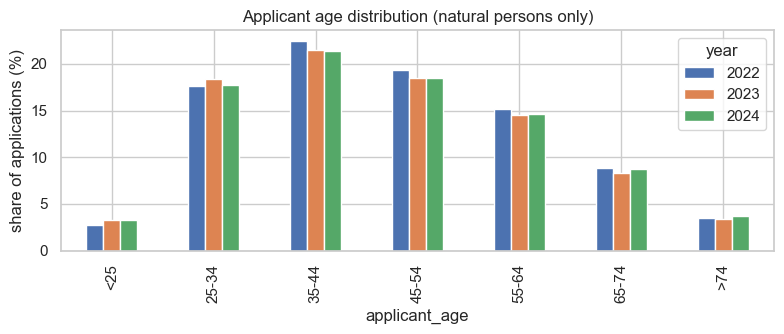

In [25]:
# Age distribution chart.
fig, ax = plt.subplots(figsize=(8, 3.5))
age_share.drop("8888", errors="ignore").mul(100).plot(kind="bar", ax=ax)
ax.set_ylabel("share of applications (%)")
ax.set_title("Applicant age distribution (natural persons only)")
ax.legend(title="year")
plt.tight_layout()
plt.show()

## 11. Who gets denied, and why?

Conditional on `action_taken = 3` (denied). `denial_reason-1` carries the primary reason; secondary reasons live in slots 2 to 4 and are almost always null. Code 10 means not applicable and should only show up on non-denied rows, so it should be absent here. Code 1111 is partial exemption on the reason field.

Then a denial-reason-by-race cross-tab, restricted to the denied population, with a 1,000-application sample-size guardrail per cell. Cells below the threshold are blanked so tiny numbers do not drive headlines. This is descriptive, not causal. Re-read the HMDA-limitation disclaimer at the top of section 9.

In [26]:
DENIAL_REASON_LABELS = {
    "1": "1 DTI ratio",
    "2": "2 employment history",
    "3": "3 credit history",
    "4": "4 collateral",
    "5": "5 insufficient cash (downpayment or closing costs)",
    "6": "6 unverifiable information",
    "7": "7 credit application incomplete",
    "8": "8 mortgage insurance denied",
    "9": "9 other",
    "10": "10 not applicable",
    "1111": "1111 exempt",
}

denial_rows = []
for year in YEARS:
    df = con.execute(
        f'SELECT "denial_reason-1" AS value, COUNT(*) AS n '
        f"FROM {TABLES[year]} WHERE action_taken = '3' "
        f'GROUP BY "denial_reason-1"'
    ).fetchdf().assign(year=year)
    denial_rows.append(df)
denial_df = pd.concat(denial_rows, ignore_index=True)
denial_share = denial_df.pivot(index="value", columns="year", values="n").fillna(0).astype(int)
denial_share = denial_share.div(denial_share.sum(axis=0), axis=1).round(4)
denial_share.index = [DENIAL_REASON_LABELS.get(i, i) for i in denial_share.index]
denial_share.index.name = "denial_reason-1"
denial_share

year,2022,2023,2024
denial_reason-1,,,
1 DTI ratio,0.3102,0.3389,0.3216
1111 exempt,0.0090,0.0126,0.0135
2 employment history,0.0126,0.0113,0.0095
3 credit history,0.2758,0.2775,0.2693
4 collateral,0.1318,0.1295,0.1280
5 insufficient cash (downpayment or closing costs),0.0196,0.0189,0.0236
6 unverifiable information,0.0423,0.0366,0.0389
7 credit application incomplete,0.1141,0.0973,0.1193
8 mortgage insurance denied,0.0003,0.0002,0.0002


**What this shows.** Primary denial reasons on denied applications (action_taken = 3) cluster on three codes year after year: DTI (32 percent in 2024), credit history (27 percent), and collateral (13 percent). Credit-application-incomplete (7) picks up roughly 12 percent. The "other" bucket (9) is a reminder that HMDA denial-reason codes are coarse; the real underwriting reasons often do not map cleanly. Code 10 is absent because the filter pins to denied rows only.

**Why it matters.** When denial mix is published per lender or per demographic group, always surface all three top codes (DTI, credit, collateral) together. Reporting only "DTI-driven denial rate" in isolation masks the credit and collateral stories. The "other" bucket size caps how granular any denial-reason dashboard card can be.

In [27]:
# Denial reason by derived_race for 2024, with 1000-application guardrail.
year = 2024
df = con.execute(
    f'SELECT derived_race AS race, "denial_reason-1" AS reason, COUNT(*) AS n '
    f"FROM {TABLES[year]} WHERE action_taken = '3' "
    f'GROUP BY derived_race, "denial_reason-1"'
).fetchdf()

# Pivot: rows = race, cols = reason
pivot = df.pivot(index="race", columns="reason", values="n").fillna(0).astype(int)
# Blank cells below guardrail.
guardrail = 1000
masked = pivot.where(pivot >= guardrail)

# Per-row shares (out of denials for that race).
row_totals = pivot.sum(axis=1)
share = pivot.div(row_totals, axis=0).round(4)
share_masked = share.where(pivot >= guardrail)

# Keep only races with at least guardrail denials in any cell.
share_masked = share_masked.loc[row_totals >= guardrail]
# Reorder reason columns and relabel.
ordered_reasons = [r for r in ["1", "2", "3", "4", "5", "6", "7", "8", "9"] if r in share_masked.columns]
share_masked = share_masked[ordered_reasons]
share_masked.columns = [DENIAL_REASON_LABELS.get(c, c) for c in share_masked.columns]
share_masked

,1 DTI ratio,2 employment history,3 credit history,4 collateral,5 insufficient cash (downpayment or closing costs),6 unverifiable information,7 credit application incomplete,8 mortgage insurance denied,9 other
race,,,,,,,,,
2 or more minority races,0.3454,NaN,0.3235,NaN,NaN,NaN,NaN,NaN,NaN
American Indian or Alaska Native,0.3139,NaN,0.3456,0.1017,NaN,NaN,0.0845,NaN,0.0711
Asian,0.4244,0.0116,0.1660,0.1285,0.0277,0.0441,0.1035,NaN,0.0870
Black or African American,0.3094,0.0087,0.3524,0.1015,0.0252,0.0366,0.0863,NaN,0.0699
Free Form Text Only,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Joint,0.2887,NaN,0.3292,0.1246,NaN,0.0396,0.0875,NaN,0.0821
Native Hawaiian or Other Pacific Islander,0.3665,NaN,0.2865,NaN,NaN,NaN,NaN,NaN,NaN
Race Not Available,0.2824,0.0091,0.2234,0.1246,0.0259,0.0442,0.1986,NaN,0.0769
White,0.3292,0.0097,0.2718,0.1363,0.0221,0.0371,0.1027,NaN,0.0761


**What this shows.** Within denied applications, the DTI-credit-collateral ranking holds across every race bucket with enough denials to report. The rank order moves: credit history is a larger share of denials for some groups, collateral for others. Cells below the 1,000-denial guardrail for 2024 are blanked so tiny denominators do not produce inflated percentages.

**Why it matters.** The finding is the rank order stability, not any specific cell. In any M3 fair-lending card, always attach the denial count alongside the percentage so readers can see the denominator. And always publish the HMDA-limitation disclaimer on the same card.

## 12. Findings to carry forward

- **Origination regime shift.** Origination rate dipped to 49.4 percent in 2023 before recovering to 50.5 percent in 2024. Denial rate rose from 15.5 to 17.2 percent across the window. 2023 is not a steady state.
- **Book composition flip.** Purpose mix flipped from refi-heavy 2022 to purchase-dominant 2023 and 2024. Any year-over-year comparison on originated loans must fix purpose before drawing a conclusion.
- **Aggregate loan-size is flat; the per-purpose story is the interesting one.** Median originated loan amount was $235k in 2022 and $235k in 2024, with a $225k dip in 2023. Home-purchase median drifted up. Refinance median swung 195 to 155 to 245 as the book contracted and then came back as a smaller, higher-balance cohort. Per-purpose medians are the honest cut.
- **Pricing excludes the partial-exempt panel.** Interest-rate and rate-spread percentiles here are from full reporters only. Any M3 pricing dashboard must declare the filter and segment out the 41 percent of 2024 reporters using partial exemption.
- **LTV usable as continuous, DTI must stay bucketed.** LTV is clean numeric; DTI's hybrid bucket/int encoding forces categorical treatment. Document both in the data dictionary and dbt staging.
- **Business-purpose is a small but meaningful slice.** 6 to 7 percent of HMDA applications across the window. Consumer-lending cuts filter it out; lender-class segmentation uses it.
- **Demographic disclosure gaps are material.** Roughly one in four applicants falls in `Race Not Available` or `Sex Not Available`. Any disparity analysis must publish the gap rate alongside the result.
- **Denial-reason mix concentrates on three codes.** DTI, credit history, collateral. Headlines on any single code in isolation are misleading; always surface the rank.
- **Sample-size guardrails are real.** Denial-reason-by-demographic cross-tabs need a minimum-cell threshold (this notebook uses 1,000). Without it, tiny cells drive spurious disparity readings.
- **SYB outperforms on origination rate.** Stock Yards originates ~65 percent of applications every year, ~15 points above market. Stable through the shock. First quantitative evidence of the SYB anchor as a conservative community-bank posture.

## Persist findings to /docs/

One-line invocation of `scripts/eda_02_docs.py`. The helper idempotently replaces the delimited blocks in `/docs/data-quality-notes.md` (dated EDA-02 block) and `/docs/methodology.md` (metric-definition block for M3 dashboard surfaces).

In [28]:
dq_path, meth_path = persist_findings(
    action_share=action_share,
    loan_purpose_share=loan_purpose_share,
    loan_amount_df=loan_amount_df,
    la_purpose_pivot=la_purpose_pivot,
    income_df=income_df,
    pricing_df=pricing_df,
    ltv_df=ltv_df,
    dti_share=dti_share,
    race_share=race_share,
    ethnicity_share=ethnicity_share,
    sex_share=sex_share,
    age_share=age_share,
    denial_share=denial_share,
    denial_by_race=share_masked,
    syb_outcome_df=syb_outcome_df,
    years=YEARS,
    repo_root=REPO_ROOT,
)
print(f"updated {dq_path.relative_to(REPO_ROOT)}")
print(f"updated {meth_path.relative_to(REPO_ROOT)}")

updated docs/data-quality-notes.md
updated docs/methodology.md


In [29]:
con.close()
print("done")

done
